In [1]:
pip install tf_keras

DEPRECATION: pytorch-lightning 1.7.7 has a non-standard dependency specifier torch>=1.9.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.3.1 -> 24.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import logging
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
os.environ['TF_USE_LEGACY_KERAS'] = 'True'
# TensorFlowの警告を非表示にする
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0 = all messages are logged, 1 = filter out INFO messages, 2 = filter out WARNING messages, 3 = filter out ERROR messages

# Pythonのloggingモジュールを使用して警告を非表示にする
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [4]:
#コーギーの尻と食パンを見分ける
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
import glob, pathlib

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"TensorFlow has detected {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected by TensorFlow.")

TensorFlow has detected 1 GPU(s):
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [23]:
def main():
    #画像取得
    '''
    input_dir = "dataset"
    data_dir = pathlib.Path(input_dir)
    input_list = list(data_dir.glob('**/*.jpg'))
    print("files:", len(input_list))
    for i in range(len(input_list)):
        img_file_name = str(input_list[i])
        img_np = np.fromfile(img_file_name, dtype=np.uint8)
        #print("-------------------------------------------")
        #print(img_file_name)

    corgies = list(input_dir.glob("corgies/*"))
    breads = list(input_dir.glob("breads/*"))

    #なぜか機能しない
    PIL.Image.open(str(corgies[0]))
    '''
    
    class_names = ["breads", "corgies"]
    print(class_names)

    TRAINING_DIR = "dataset/training"
    VALIDATION_DIR = "dataset/validation"

    
    train_class_counts = count_images_in_directory(TRAINING_DIR)
    val_class_counts = count_images_in_directory(VALIDATION_DIR)
    
    print("Training class counts:", train_class_counts)
    print("Validation class counts:", val_class_counts)

    train_generator, validation_generator = train_val_generators(TRAINING_DIR, VALIDATION_DIR)
    #print("train_generator:", train_generator[0])
    #return
    #model = create_model()
    model = use_model()

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)
    history = model.fit(train_generator,\
                    epochs=50,\
                    verbose=1,\
                    validation_data=validation_generator,
                    callbacks=[early_stopping, reduce_lr]
   )
    model.save('image-classification.h5')
    try_classification(model, class_names)
    plot_learning(history)

In [24]:
def train_val_generators(TRAINING_DIR, VALIDATION_DIR):
    #TODO : ラベルを変更
    #前処理
    params = {
        'zoom_range': [0.2, 2.0], 
        'rotation_range': 90, 
        'vertical_flip': True,
        'horizontal_flip': True
        
    }

    train_datagen = ImageDataGenerator(zoom_range=[0.2, 2.0], rotation_range=90, vertical_flip=True,horizontal_flip=True, \
                                       rescale=1.0/255.0)
    train_generator = train_datagen.flow_from_directory(directory=TRAINING_DIR, batch_size=30, target_size=(150, 150), class_mode='binary')
    validation_datagen = ImageDataGenerator(rescale=1.0/255.0)
    validation_generator = validation_datagen.flow_from_directory(directory=VALIDATION_DIR,\
                                                                batch_size=20,\
                                                                target_size=(150, 150), class_mode='binary')
    #print(train_datagen)
    
    items = next(iter(train_generator))

    plt.figure(figsize=(12,12))
    for i, image in enumerate(items[0][:25], 1):
        plt.subplot(5,5,i)
        plt.imshow(image)
        plt.axis('off')
    plt.show()
    

    return train_generator, validation_generator

In [25]:
def create_model():

  model = tf.keras.models.Sequential([ 
    tf.keras.layers.Conv2D(16, (4,4), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (4,4), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2), 
    tf.keras.layers.Conv2D(64, (4,4), activation='relu'), 
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'), 
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'), 
    tf.keras.layers.Dense(1, activation='sigmoid')  
  ])
  
  model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy']) 

  return model

In [26]:
def use_model():
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.2),
    ])


    IMG_SIZE = (150, 150)
    IMG_SHAPE = IMG_SIZE + (3,)
    base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,\
                                               include_top=False,\
                                               weights='imagenet')
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
    global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
    prediction_layer = tf.keras.layers.Dense(1)
    #softmax_layer = tf.keras.layers.Dense(2, activation='softmax')
    inputs = tf.keras.Input(shape=(150, 150, 3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=True)
    x = global_average_layer(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = prediction_layer(x)
    #x = prediction_layer(x)
    #outputs = softmax_layer(x)
    model = tf.keras.Model(inputs, outputs)
    #print(model.summary())
    
    base_learning_rate = 0.0001
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])
    model.save('image-classification.h5')
    #print(len(model.trainable_variables))

    return model

In [27]:
def plot_learning(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))
    plt.figure()
    plt.plot(epochs, acc, 'r', label='leaning accuracy')
    plt.plot(epochs, val_acc, 'b', label='validation accuracy')
    plt.title('accuracy')
    plt.legend()
    plt.show()

    plt.figure()
    
    plt.plot(epochs, loss, 'r', label='leaning error')
    plt.plot(epochs, val_loss, 'b', label='validation error')
    plt.title('error')
    plt.legend()

    plt.show()


In [28]:
def try_classification(model_load, class_names):
    #model_load = tf.keras.models.load_model('image-classification.h5')

    TEST_DIR = "inputhere"
    test_datagen = ImageDataGenerator(rescale=1.0/255.0)
    test_generator = test_datagen.flow_from_directory(directory=TEST_DIR,\
                                                                batch_size=10,\
                                                                target_size=(150, 150), class_mode='binary')

    loss, accuracy = model_load.evaluate(test_generator)
    print('Test accuracy :', accuracy)

    # Retrieve a batch of images from the test set
    image_batch, label_batch = test_generator.next()
    predictions = model_load.predict_on_batch(image_batch).flatten()
    print('Predictions/before:\n', predictions)

    # Apply a sigmoid since our model returns logits
    
    # mobilenet使う時はこっち 
    predictions = tf.nn.sigmoid(predictions)
    predictions = tf.where(predictions < 0.5, 0, 1)

    print('Predictions:\n', predictions.numpy())
    print('Labels:\n', label_batch)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i])
        plt.title(class_names[predictions[i]])
        plt.axis("off")



    '''
    data_dir = pathlib.Path(input_dir)
    input_list = list(data_dir.glob('*.jpg'))
    input_list += list(data_dir.glob('*.jpeg'))
    input_list += list(data_dir.glob('*.png'))
    for i in range(len(input_list)):
        img_file_name = str(input_list[i])  
        print(img_file_name)
        img = load_img(img_file_name, target_size=(150, 150))
        x = img_to_array(img)
        x /= 255        
        x = np.expand_dims(x, axis=0)

       

        classes = model_load.predict(x)
        print("classes:", classes)
        #index = np.argmax(classes[0])
        if classes[0][0] < 0:
            print('bread')
        else:
            print('Corgi')

    plt.imshow(x[0])
    plt.show()
    '''





In [29]:

def count_images_in_directory(directory):
    class_counts = {}
    for class_dir in os.listdir(directory):
        class_path = os.path.join(directory, class_dir)
        if os.path.isdir(class_path):
            class_counts[class_dir] = len(os.listdir(class_path))
    return class_counts

['breads', 'corgies']
Training class counts: {'breads': 191, 'corgies': 287}
Validation class counts: {'breads': 34, 'corgies': 30}
Found 476 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


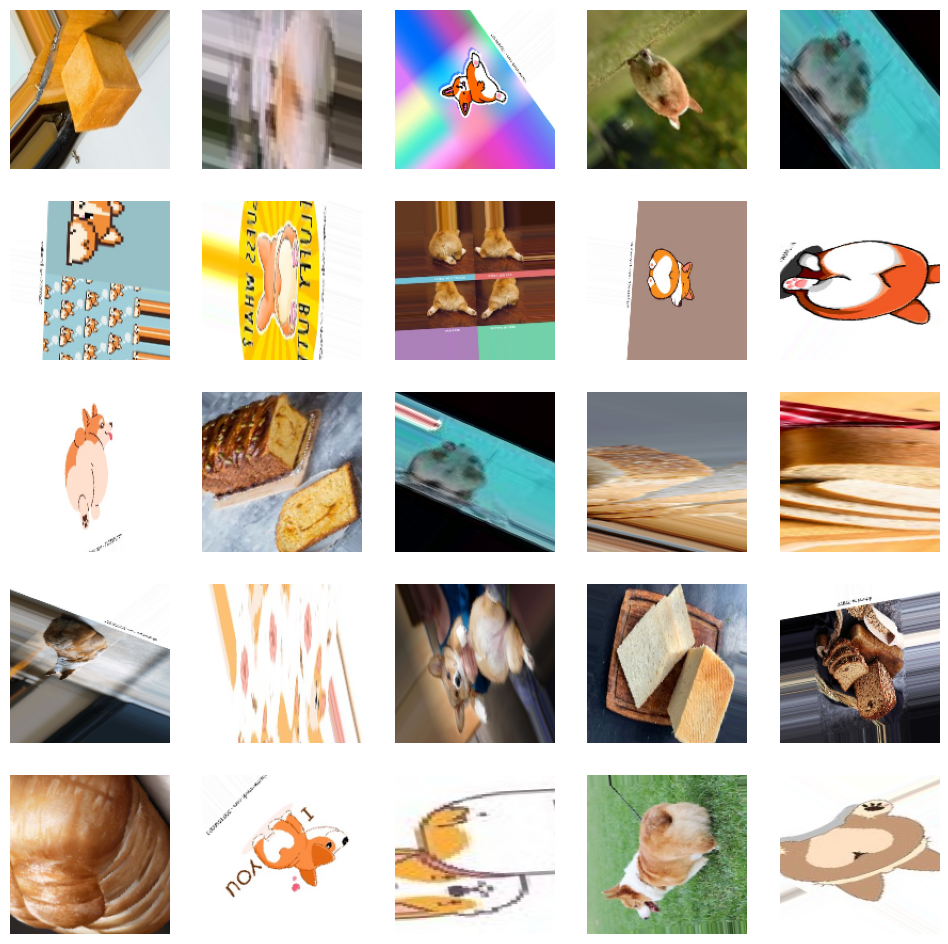

Epoch 1/50
16/16 [==============================] - 13s 365ms/step - loss: 0.5585 - accuracy: 0.6912 - val_loss: 0.3701 - val_accuracy: 0.8871 - lr: 1.0000e-04
Epoch 2/50
16/16 [==============================] - 3s 165ms/step - loss: 0.3464 - accuracy: 0.8592 - val_loss: 0.3739 - val_accuracy: 0.8548 - lr: 1.0000e-04
Epoch 3/50
16/16 [==============================] - 3s 164ms/step - loss: 0.2820 - accuracy: 0.8866 - val_loss: 0.2961 - val_accuracy: 0.8871 - lr: 1.0000e-04
Epoch 4/50
16/16 [==============================] - 3s 161ms/step - loss: 0.2957 - accuracy: 0.8613 - val_loss: 0.3467 - val_accuracy: 0.8871 - lr: 1.0000e-04
Epoch 5/50
16/16 [==============================] - 3s 164ms/step - loss: 0.2551 - accuracy: 0.8845 - val_loss: 0.3488 - val_accuracy: 0.8548 - lr: 1.0000e-04
Epoch 6/50
16/16 [==============================] - 3s 167ms/step - loss: 0.2469 - accuracy: 0.8971 - val_loss: 0.3679 - val_accuracy: 0.8548 - lr: 1.0000e-04
Epoch 7/50
16/16 [===========================

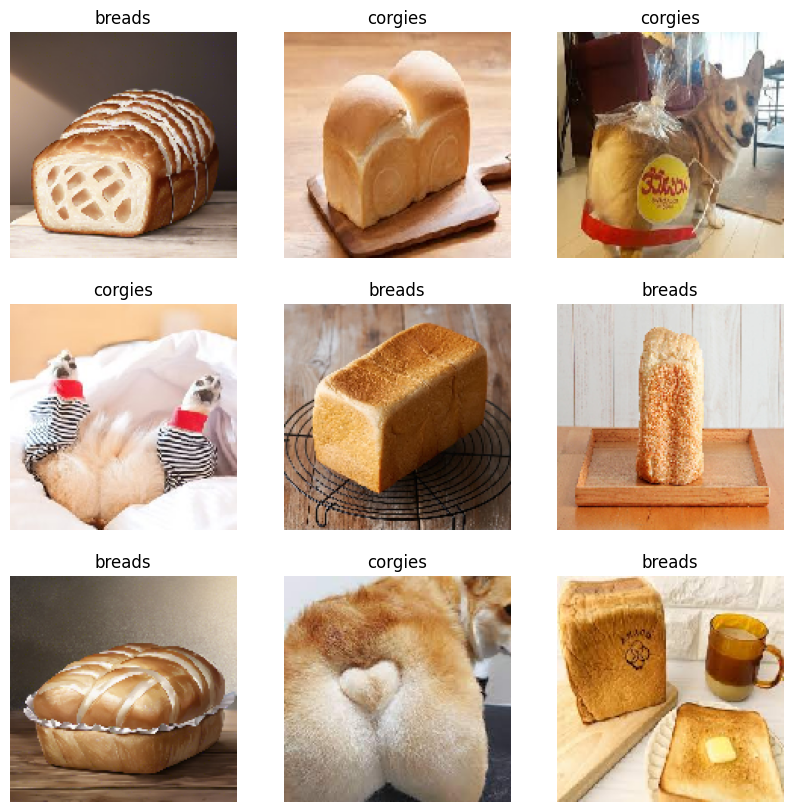

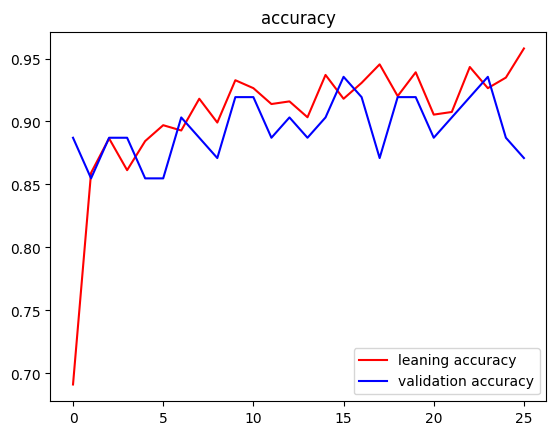

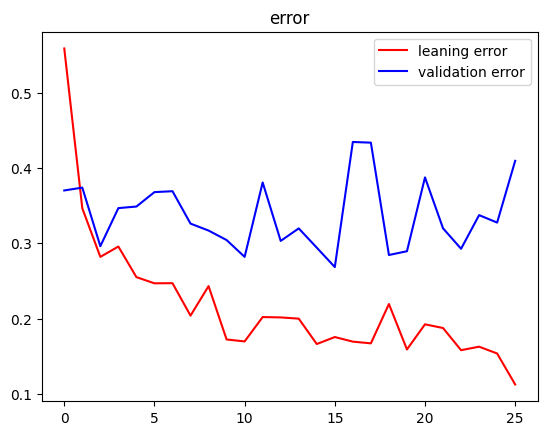

In [31]:
main()